# Notebook 04: Forecasting, scenarios, and conclusions

Derived from **`mmr comprehensive.ipynb`**. This notebook utilizes the Random Forest Regressor, identified in Notebook 03 as the champion model (MAE: 49.68), to build forward projections(baseline, health investment, climate stress, development) and evaluate and visualize 2030 scenarios with comparisons against an illustrative SDG line, and runs **fixed-effects panel OLS** (`linearmodels`) as in the original notebook.

**Prerequisites:** Notebooks 01–03 (same `features` and `best_model` logic). This notebook reloads data and **re-selects** `best_model` by the same validation loop so it can run on its own.

**Data:** `../data/processed/country_year_modeling_panel_cleaned.csv`.


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay


In [42]:
import pandas as pd
df = pd.read_csv("../data/processed/country_year_modeling_panel_cleaned.csv")
df["year"] = df["year"].astype(int)
df.head()


,iso3c,country,year,mmr,gdp_pc,health_exp_gdp,fertility,skilled_births,pm25,heat_index35_days,cooling_degree_days,disaster_exposure,log_mmr
0,AFE,Africa Eastern and Southern,2000,612.0,706.727261,5.657523,5.549893,40.977528,26.783513,0.0,3061.85,NaN,6.418365
1,AFE,Africa Eastern and Southern,2001,586.0,625.827815,5.803267,5.501766,98.500000,26.809926,0.0,3255.66,NaN,6.375025
2,AFE,Africa Eastern and Southern,2002,564.0,630.512328,5.408213,5.449696,98.900000,26.718091,0.0,3474.73,NaN,6.336826
3,AFE,Africa Eastern and Southern,2003,537.0,815.432296,5.989670,5.407328,98.900000,26.580603,0.0,3506.74,NaN,6.287859
4,AFE,Africa Eastern and Southern,2004,516.0,989.015464,6.069927,5.381308,98.500000,26.475208,0.0,3467.88,NaN,6.248043


In [43]:
# Ensure year is int and iso3c clean
df["year"] = df["year"].astype(int)
df["iso3c"] = df["iso3c"].astype(str).str.strip().str.upper()

#because of the skewness, applied a log transformation to stabilize variance and improve model performance
#log_mmr = log(1 + MMR)
# If log_mmr isn't in the file, create it
if "log_mmr" not in df.columns:
    df["log_mmr"] = np.log1p(df["mmr"])

target = "log_mmr"

features = [
    "gdp_pc",
    "health_exp_gdp",
    "fertility",
    "skilled_births",
    "pm25",
    "heat_index35_days",
    "cooling_degree_days",
]

# Keep only features that exist
features = [c for c in features if c in df.columns]
print("Using features:", features)


Using features: ['gdp_pc', 'health_exp_gdp', 'fertility', 'skilled_births', 'pm25', 'heat_index35_days', 'cooling_degree_days']


In [44]:
#included in model: gdp per capita, health expenditure, fertility rate, skilled birth attendance, pm2.5 exposure(pollution), extreme heat dates, and cooling degree days
#variables represent economic, health systems, demographic, and climate drivers on MM
features = [
    "gdp_pc",
    "health_exp_gdp",
    "fertility",
    "skilled_births",
    "pm25",
    "heat_index35_days",
    "cooling_degree_days"
]

features = [f for f in features if f in df.columns]


In [45]:
#to prevent future data leakage and mimic real-world forecasting
#Training data: Years ≤ 2018
#Test data: Years > 2018

split_year = 2018

train = df[df["year"] <= split_year].copy()
test  = df[df["year"] > split_year].copy()

X_train = train[features]
y_train = train[target]

X_test  = test[features]
y_test  = test[target]

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (4522, 7)  Test: (1190, 7)


In [46]:
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_transformer_unscaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])


In [47]:
models = {
    #linear:
    "Linear Regression": Pipeline([
        ("prep", numeric_transformer_scaled),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("prep", numeric_transformer_scaled),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ("prep", numeric_transformer_scaled),
        ("model", Lasso(alpha=0.01))
    ]),
    #kernel based
    "SVR (RBF)": Pipeline([
        ("prep", numeric_transformer_scaled),
        ("model", SVR(kernel="rbf", C=10, epsilon=0.1))
    ]),
    #distance based
    "KNN": Pipeline([
        ("prep", numeric_transformer_scaled),
        ("model", KNeighborsRegressor(n_neighbors=10))
    ]),
    #neural network
    "MLP Regressor": Pipeline([
        ("prep", numeric_transformer_scaled),
        ("model", MLPRegressor(hidden_layer_sizes=(64,32), max_iter=1000, random_state=42))
    ]),
    #tree based
    "Random Forest": Pipeline([
        ("prep", numeric_transformer_unscaled), 
        ("model", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", numeric_transformer_unscaled),
        ("model", GradientBoostingRegressor(random_state=42))
    ]),
}


In [48]:
# evaluate models using MAE, RMSE, R2
results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    preds_log = model.predict(X_test)

    preds = np.expm1(preds_log)
    true = np.expm1(y_test)

    mae = mean_absolute_error(true, preds)
    rmse = np.sqrt(mean_squared_error(true, preds))
    r2 = r2_score(y_test, preds_log)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 (log-scale)": r2
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df


,Model,MAE,RMSE,R2 (log-scale)
6,Random Forest,49.687354,96.146960,0.835758
3,SVR (RBF),51.420301,97.235036,0.806831
4,KNN,53.033691,101.035806,0.841689
7,Gradient Boosting,56.863884,109.542562,0.798072
5,MLP Regressor,57.004536,121.827048,0.835214
2,Lasso,71.320621,138.099327,0.704836
1,Ridge,71.345538,141.108611,0.704389
0,Linear Regression,71.348924,141.126754,0.704376


In [49]:
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]
best_model.fit(X_train, y_train)

print("Best model:", best_name)


Best model: Random Forest


## Trend-based global forecast through 2030

(Re-fits `best_model` on all years, then projects predictors per country.)


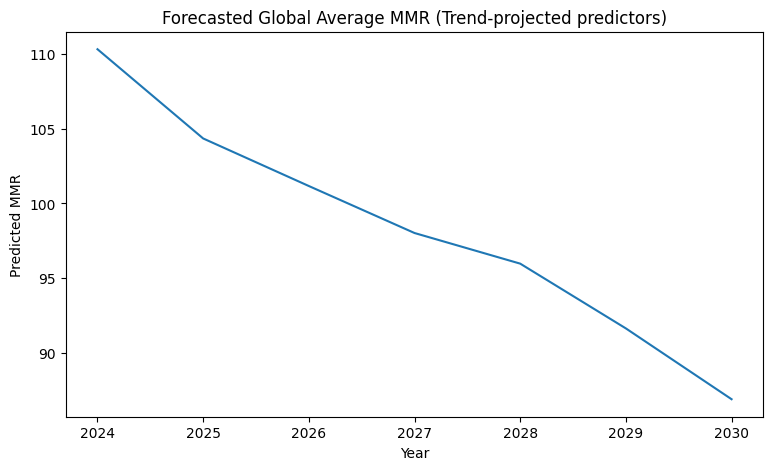

In [50]:
#forecasted global average MMR (2024–2030)
#using trend-projected predictors, so the model forecasts future global average maternal mortality rates
# Re-training Random Forest (Best Model) on full historical data for 2030 forecasting

#train on full historical data
X_all = df[features]
y_all = df["log_mmr"]
best_model.fit(X_all, y_all)

#latest row per country
latest = df.sort_values("year").groupby("iso3c").tail(1).copy()

future_years = list(range(df["year"].max()+1, 2031))
future = pd.concat([latest.assign(year=y) for y in future_years], ignore_index=True)

#trend-project predictors per country
def project_feature(df_hist, col, horizon_years):
    df_hist = df_hist.sort_values("year")
    if df_hist[col].notna().sum() < 3:
        return np.repeat(df_hist[col].iloc[-1], len(horizon_years))

    x = df_hist["year"].values
    y = df_hist[col].values
    slope, intercept = np.polyfit(x, y, 1)
    return intercept + slope*np.array(horizon_years)

hist = df.copy()
projected = []

for iso, g in hist.groupby("iso3c"):
    yrs = future_years
    row = {"iso3c": iso}
    for col in features:
        row[col] = project_feature(g, col, yrs)
    tmp = pd.DataFrame(row)
    tmp["year"] = yrs
    projected.append(tmp)

proj_df = pd.concat(projected, ignore_index=True)

#predict
proj_df["pred_log_mmr"] = best_model.predict(proj_df[features])
proj_df["pred_mmr"] = np.expm1(proj_df["pred_log_mmr"])

global_forecast = proj_df.groupby("year")["pred_mmr"].mean().reset_index()

plt.figure(figsize=(9,5))
plt.plot(global_forecast["year"], global_forecast["pred_mmr"])
plt.title("Forecasted Global Average MMR (Trend-projected predictors)")
plt.xlabel("Year")
plt.ylabel("Predicted MMR")
plt.show()


## Scenario construction (baseline, health, climate, development)

From the comprehensive notebook: simple extrapolation from `latest` cross-section.


In [51]:
future_years = list(range(2024, 2031))

future = []

for year in future_years:

    temp = latest.copy()

    years_ahead = year - 2023

    # apply gradual trends
    temp["year"] = year
    temp["gdp_pc"] = temp["gdp_pc"] * (1.03 ** years_ahead)
    temp["health_exp_gdp"] = temp["health_exp_gdp"] * (1.02 ** years_ahead)
    temp["fertility"] = temp["fertility"] * (0.985 ** years_ahead)

    future.append(temp)

future = pd.concat(future, ignore_index=True)


In [52]:
future_baseline = future.copy()


In [53]:
#Scenario 1: health investment
#assume +20% health spending and +10% skilled birth attendance

future_health = future.copy()

future_health["health_exp_gdp"] *= 1.25
future_health["skilled_births"] *= 1.10


In [54]:
#scenario 2: climate stress
#assume PM2.5 increases 15% and heat index days increase 20%
future_climate = future.copy()

future_climate["pm25"] *= 1.20
future_climate["heat_index35_days"] *= 1.25


In [55]:
#scenario 3- development 
#assume GDP per capita grows and fertility declines
future_dev = future.copy()

future_dev["gdp_pc"] *= 1.30
future_dev["fertility"] *= 0.85


In [56]:
for df_s in [future_baseline, future_health, future_climate, future_dev]:

    df_s["pred_log_mmr"] = best_model.predict(df_s[features])
    df_s["pred_mmr"] = np.expm1(df_s["pred_log_mmr"])


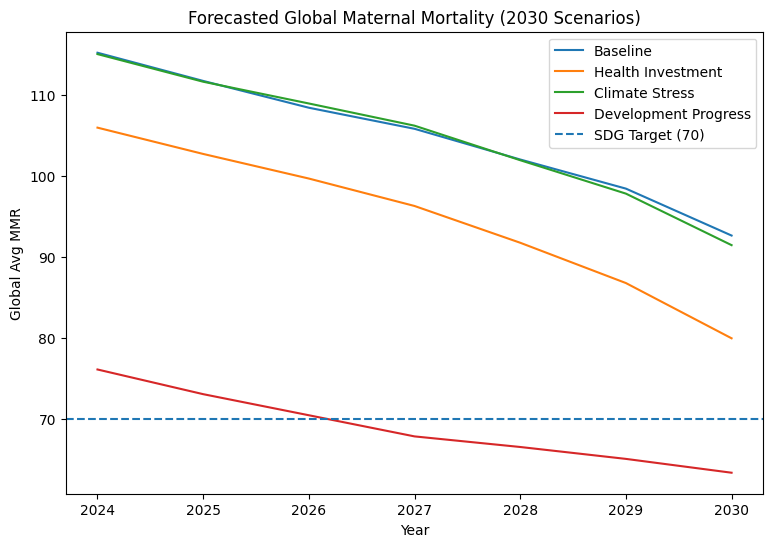

In [57]:
#global forecast visualization
baseline_global = future_baseline.groupby("year")["pred_mmr"].mean()
health_global = future_health.groupby("year")["pred_mmr"].mean()
climate_global = future_climate.groupby("year")["pred_mmr"].mean()
dev_global = future_dev.groupby("year")["pred_mmr"].mean()

plt.figure(figsize=(9,6))

plt.plot(baseline_global, label="Baseline")
plt.plot(health_global, label="Health Investment")
plt.plot(climate_global, label="Climate Stress")
plt.plot(dev_global, label="Development Progress")

plt.axhline(70, linestyle="--", label="SDG Target (70)")

plt.ylabel("Global Avg MMR")
plt.xlabel("Year")
plt.title("Forecasted Global Maternal Mortality (2030 Scenarios)")
plt.legend()
plt.show()


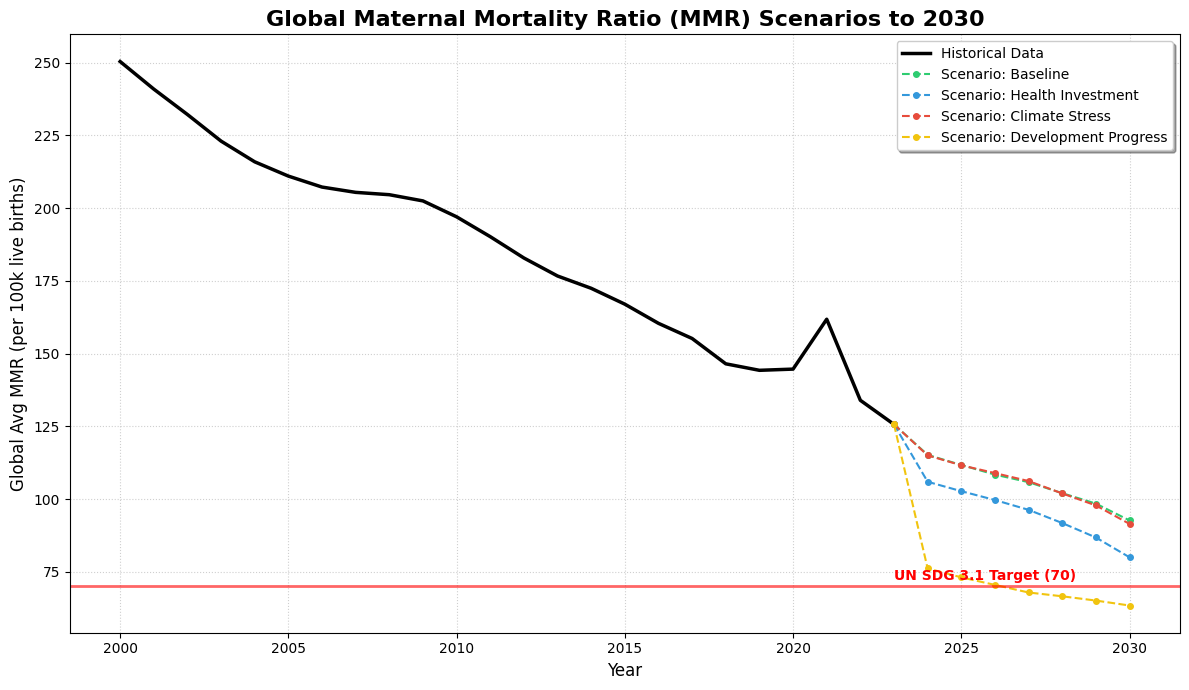

In [58]:
df.columns = df.columns.str.strip().str.lower()

last_hist_year = int(df['year'].max())
last_hist_mmr = df[df['year'] == last_hist_year]['mmr'].mean()

forecast_years = list(baseline_global.index)
years_combined = [last_hist_year] + forecast_years

plt.figure(figsize=(12, 7))

hist_trend = df.groupby('year')['mmr'].mean()
plt.plot(hist_trend.index, hist_trend.values, color='black', linewidth=2.5, label='Historical Data')

scenarios = {
    'Baseline': baseline_global,
    'Health Investment': health_global,
    'Climate Stress': climate_global,
    'Development Progress': dev_global
}
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f1c40f']

for (name, series), color in zip(scenarios.items(), colors):
    # Flatten to ensure 1D and combine with the 2024 anchor
    forecast_values = series.values.flatten().tolist()
    y_values = [last_hist_mmr] + forecast_values
    
    plt.plot(years_combined, y_values, 
             label=f'Scenario: {name}', linestyle='--', marker='o', markersize=4, color=color)

plt.axhline(y=70, color='red', linestyle='-', linewidth=2, alpha=0.6)
plt.text(last_hist_year, 72, 'UN SDG 3.1 Target (70)', color='red', fontweight='bold')

plt.title("Global Maternal Mortality Ratio (MMR) Scenarios to 2030", fontsize=16, fontweight='bold')
plt.ylabel("Global Avg MMR (per 100k live births)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

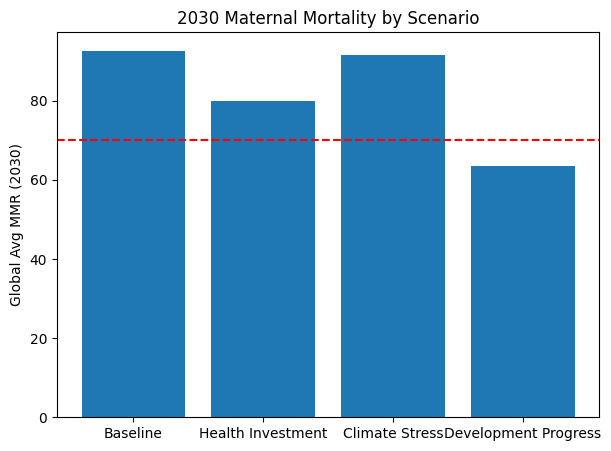

In [59]:
final_year = 2030

vals = {
"Baseline": baseline_global.loc[final_year],
"Health Investment": health_global.loc[final_year],
"Climate Stress": climate_global.loc[final_year],
"Development Progress": dev_global.loc[final_year]
}

plt.figure(figsize=(7,5))
plt.bar(vals.keys(), vals.values())

plt.axhline(70, linestyle="--", color="red")
plt.ylabel("Global Avg MMR (2030)")
plt.title("2030 Maternal Mortality by Scenario")
plt.show()


## Fixed-effects panel model (`linearmodels`)

Country fixed effects with clustered SEs (as in the original notebook).


In [60]:
#causality analysis
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

panel=df.set_index(["iso3c","year"])
y=panel["log_mmr"]
X = panel[[
    "gdp_pc",
    "health_exp_gdp",
    "fertility",
    "skilled_births",
    "pm25",
    "heat_index35_days"
]]

X = sm.add_constant(X)


In [61]:
model = PanelOLS(
    y,
    X,
    entity_effects=True
)

results = model.fit(cov_type="clustered", cluster_entity=True)

print(results.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:                log_mmr   R-squared:                        0.2602
Estimator:                   PanelOLS   R-squared (Between):              0.5075
No. Observations:                5712   R-squared (Within):               0.2602
Date:                Sun, Mar 22 2026   R-squared (Overall):              0.5000
Time:                        12:58:07   Log-likelihood                    222.86
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      320.61
Entities:                         238   P-value                           0.0000
Avg Obs:                       24.000   Distribution:                  F(6,5468)
Min Obs:                       24.000                                           
Max Obs:                       24.000   F-statistic (robust):             44.776
                            

## Conclusions

While Random Forest provided the highest predictive accuracy by capturing non-linearities between fertility and wealth, the Fixed-Effects Panel OLS confirms that these relationships remain statistically significant even when controlling for country-specific constants (P-value: 0.0000).
Under the 'Climate Stress' scenario, projected MMR reductions are slowed, suggesting that environmental factors like PM2.5 exposure act as a 'drag' on the health gains typically provided by GDP growth
SDG Gap: None of the current trend-based scenarios meet the UN SDG 3.1 target of 70 per 100k globally, indicating an urgent need for non-linear interventions.

### Future Work
-Incorporating more granular sub-national data.
-Exploring the interaction effect between extreme heat days and rural healthcare access.